<div class="jumbotron text-left"><b>
    
This tutorial describes how to use de DesignSpace within the SMT toolbox.
<div>
    
    February 2026 - `SMT version 2.10.1`
  
     Paul Saves (IRIT/SMAC), Jasper Bussemaker (DLR), Rémi Lafage (ONERA/DTIS/MIDL) and Nathalie BARTOLI (ONERA/DTIS/M2CI)

<div class="alert alert-info fade in" id="d110">
<p>Some updates</p>
<ol> -  Manipulation of mixed DOE (continuous, integer,  categorical and hierarchical variables) </ol>
</div>

<p class="alert alert-success" style="padding:1em">
To use SMT models, please follow this link : https://github.com/SMTorg/SMT/blob/master/README.md. The documentation is available here: http://smt.readthedocs.io/en/latest/
</p>

The reference paper is available
here https://www.sciencedirect.com/science/article/pii/S096599782300162X



For mixed integer with continuous relaxation, the reference paper is available here https://www.sciencedirect.com/science/article/pii/S0925231219315619

In [1]:
# to have the latest version
!pip install configspace
!pip install adsg-core
!pip install smt-design-space-ext
!pip install smt
!pip install "adsg-core[nb]"

  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached jupyterlab_server-2.28.0-py3-none-any.whl.metadata (5.9 kB)
  Using cached notebook_shim-0.2.4-py3-none-any.whl.metadata (4.0 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached argon2_cffi-25.1.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached jupyter_server_terminals-0.5.4-py3-none-any.whl.metadata (5.9 kB)
  Using cached overrides-7.7.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached send2trash-2.1.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached terminado

<div class="alert alert-warning" >
If you use hierarchical variables and the size of your doe greater than 30 points, you may leverage the `numba` JIT compiler to speed up the computation
To do so:
    
 - install numba library
    
     `pip install numba`
    
    
 - and define the environment variable `USE_NUMBA_JIT = 1` (unset or 0 if you do not want to use numba)
    
     - Linux: export USE_NUMBA_JIT = 1
    
     - Windows: set USE_NUMBA_JIT = 1

</div>

In [2]:
%matplotlib inline

# to ignore warning messages
import warnings

import plotly.io as pio
from smt.sampling_methods import LHS
from smt_design_space_ext import (
    AdsgDesignSpaceImpl,
    CategoricalVariable,
    ConfigSpaceDesignSpaceImpl,
    DesignSpace,
    FloatVariable,
    IntegerVariable,
    OrdinalVariable,
)

warnings.filterwarnings("ignore")

pio.renderers.default = "notebook"

# MAELIA

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from smt.design_space import FloatVariable, OrdinalVariable
from smt_design_space_ext import AdsgDesignSpaceImpl
from smt.surrogate_models import KRG

# ==========================================
# 1. PARAMÈTRES EXPLORÉS — PLAN TERRAINSA ACTUEL
# ==========================================
# Les anciens types de préparation ne sont plus explorés : ils sont remplacés
# par des profondeurs explicites. Le type d'engrais est fixé à AN.
FERTILIZER_TYPE = "AN"
PREPA_TYPE_1 = "travail_sol_1"
PREPA_TYPE_2 = "une_reprise"
SEMIS_TYPE = "semis"
PREPA_DEPTH_MIN_CM = 1.0
PREPA_DEPTH_MAX_CM = 25.0
SEMIS_DEPTH_MIN_CM = 1.0
SEMIS_DEPTH_MAX_CM = 4.0

SMT_FEATURES = [
    "n_ferti", "has_prepa", "nb_prepa",
    "Date_Semis", "Delta_PREPA_Semis", "Profondeur_Semis",
    "Profondeur_Prepa_1", "Profondeur_Prepa_2",
    "Date_F1", "Date_F2", "Date_F3", "Date_Recolte",
    "Dose_F1", "Dose_F2", "Dose_F3",
]
SMT_CATEGORICAL = ["n_ferti", "has_prepa", "nb_prepa"]
SMT_CONTINUOUS = [feature for feature in SMT_FEATURES if feature not in SMT_CATEGORICAL]

agri_design_space = AdsgDesignSpaceImpl(
    design_variables=[
        OrdinalVariable(["0_ferti", "1_ferti", "2_ferti", "3_ferti"]),  # 0: n_ferti
        OrdinalVariable(["Non_prepa", "Oui_prepa"]),                    # 1: has_prepa
        OrdinalVariable(["1_prepa", "2_prepa"]),                        # 2: nb_prepa
        FloatVariable(45, 106),                                          # 3: Date_Semis
        FloatVariable(-44, -4),                                          # 4: Delta_PREPA_Semis
        FloatVariable(SEMIS_DEPTH_MIN_CM, SEMIS_DEPTH_MAX_CM),           # 5: Profondeur_Semis
        FloatVariable(PREPA_DEPTH_MIN_CM, PREPA_DEPTH_MAX_CM),           # 6: Profondeur_Prepa_1
        FloatVariable(PREPA_DEPTH_MIN_CM, PREPA_DEPTH_MAX_CM),           # 7: Profondeur_Prepa_2
        FloatVariable(106, 323),                                         # 8: Date_F1
        FloatVariable(210, 323),                                         # 9: Date_F2
        FloatVariable(240, 323),                                         # 10: Date_F3
        FloatVariable(323, 384),                                         # 11: Date_Recolte
        FloatVariable(10, 100),                                          # 12: Dose_F1
        FloatVariable(10, 100),                                          # 13: Dose_F2
        FloatVariable(10, 100),                                          # 14: Dose_F3
    ]
)

# ==========================================
# 2. HIÉRARCHIE D'ACTIVATION (ADSG)
# ==========================================
# Préparation du sol active seulement si has_prepa = Oui.
agri_design_space.declare_decreed_var(decreed_var=2, meta_var=1, meta_value=["Oui_prepa"])
agri_design_space.declare_decreed_var(decreed_var=4, meta_var=1, meta_value=["Oui_prepa"])
agri_design_space.declare_decreed_var(decreed_var=6, meta_var=1, meta_value=["Oui_prepa"])
agri_design_space.declare_decreed_var(decreed_var=7, meta_var=2, meta_value=["2_prepa"])

# Fertilisation : dates et doses décrétées selon le nombre d'apports.
agri_design_space.declare_decreed_var(decreed_var=8,  meta_var=0, meta_value=["1_ferti", "2_ferti", "3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=12, meta_var=0, meta_value=["1_ferti", "2_ferti", "3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=9,  meta_var=0, meta_value=["2_ferti", "3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=13, meta_var=0, meta_value=["2_ferti", "3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=10, meta_var=0, meta_value=["3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=14, meta_var=0, meta_value=["3_ferti"])

DEFAULT_FLOATS = [
    75.0, -20.0, 3.0, 15.0, 10.0,
    150.0, 230.0, 280.0, 350.0,
    50.0, 50.0, 50.0,
]


def parse_smt_row(row_data):
    """Analyse une ligne décodée par SMT avec le plan terrainSA compact."""
    parsed = {"n_ferti": 0, "has_prepa": False, "nb_prepa": 1, "floats": []}
    values = list(row_data.values()) if isinstance(row_data, dict) else row_data
    for val in values:
        if isinstance(val, (float, int, np.floating, np.integer)):
            parsed["floats"].append(float(val))
        elif isinstance(val, str):
            if val in ["0_ferti", "1_ferti", "2_ferti", "3_ferti"]:
                parsed["n_ferti"] = int(val[0])
            elif val in ["Oui_prepa", "Non_prepa"]:
                parsed["has_prepa"] = val == "Oui_prepa"
            elif val in ["1_prepa", "2_prepa"]:
                parsed["nb_prepa"] = int(val[0])
    return parsed


def normalized_floats(parsed):
    fl = list(parsed["floats"])
    for default in DEFAULT_FLOATS[len(fl):]:
        fl.append(default)
    return fl[:len(DEFAULT_FLOATS)]


def ordered_fertilisation_dates(parsed, fl):
    dates = {"f1": None, "f2": None, "f3": None}
    if parsed["n_ferti"] >= 1:
        dates["f1"] = int(round(fl[5]))
    if parsed["n_ferti"] >= 2:
        dates["f2"] = max(int(round(fl[6])), dates["f1"] + 1)
    if parsed["n_ferti"] >= 3:
        dates["f3"] = max(int(round(fl[7])), dates["f2"] + 1)
    return dates


def extract_table_from_smt(x_array, dsg_space):
    rows = []
    decoded_data = dsg_space.decode_values(x_array)
    for row_data in decoded_data:
        p = parse_smt_row(row_data)
        fl = normalized_floats(p)
        ferti_dates = ordered_fertilisation_dates(p, fl)
        semi = int(round(fl[0]))
        prepa_date = int(round(semi + fl[1])) if p["has_prepa"] else None
        rows.append({
            "n_ferti": p["n_ferti"],
            "has_prepa": "Oui" if p["has_prepa"] else "Non",
            "nb_prepa": p["nb_prepa"] if p["has_prepa"] else "-",
            "Semi": semi,
            "Delta_PREPA_Semis": round(fl[1], 1) if p["has_prepa"] else "-",
            "Profondeur_Semis": round(fl[2], 1),
            "PREPA_Date": prepa_date if prepa_date is not None else "-",
            "Profondeur_Prepa_1": round(fl[3], 1) if p["has_prepa"] else "-",
            "Profondeur_Prepa_2": round(fl[4], 1) if p["has_prepa"] and p["nb_prepa"] == 2 else "-",
            "Ferti_1": ferti_dates["f1"] if ferti_dates["f1"] is not None else "-",
            "Dose_F1": round(fl[9], 1) if p["n_ferti"] >= 1 else "-",
            "Ferti_2": ferti_dates["f2"] if ferti_dates["f2"] is not None else "-",
            "Dose_F2": round(fl[10], 1) if p["n_ferti"] >= 2 else "-",
            "Ferti_3": ferti_dates["f3"] if ferti_dates["f3"] is not None else "-",
            "Dose_F3": round(fl[11], 1) if p["n_ferti"] >= 3 else "-",
            "Recolte": int(round(fl[8])),
            "Engrais": FERTILIZER_TYPE,
        })
    return pd.DataFrame(rows)


# ==========================================
# 3. FONCTION DUMMY POUR EXEMPLE SMT
# ==========================================
def evaluate_maelia_dummy(x_array, dsg_space):
    y = np.zeros((x_array.shape[0], 1))
    decoded_data = dsg_space.decode_values(x_array)
    for i, row_data in enumerate(decoded_data):
        p = parse_smt_row(row_data)
        fl = normalized_floats(p)
        dose_totale = 0.0
        if p["n_ferti"] >= 1:
            dose_totale += fl[9]
        if p["n_ferti"] >= 2:
            dose_totale += fl[10]
        if p["n_ferti"] >= 3:
            dose_totale += fl[11]
        y[i, 0] = 50 + (dose_totale * 0.25) - (0.0006 * dose_totale**2) + 0.1
    return y


In [4]:
N_DOE = 30  # démonstration rapide; augmenter si besoin  # démonstration rapide; augmenter si besoin
print(f"Génération de {N_DOE} points LHS hiérarchiques (SMT ADSG)...")

from smt.applications.mixed_integer import MixedIntegerSamplingMethod
from smt.sampling_methods import LHS

# On NE PASSE PLUS par xlimits_relaxed
# On donne directement le design_space (qui contient la nature des variables) au wrapper

# 1. Configuration du sampler
sampler = MixedIntegerSamplingMethod(
    LHS, 
    agri_design_space, 
    criterion="ese", 
    seed=42 # Note: SMT utilise souvent random_state au lieu de seed
)


xt_raw = sampler(N_DOE)
xt, _ = agri_design_space.correct_get_acting(xt_raw)

# --- Robust deduplication ---
def is_new(row, X, tol=1e-8):
    return not any(np.allclose(row, x, atol=tol) for x in X)

xt_unique = []
for row in xt:
    if is_new(row, xt_unique):
        xt_unique.append(row)

xt = np.array(xt_unique)

if xt.shape[0] < N_DOE:
    print("{N_DOE - xt.shape[0]} duplicates after projection")

# --- Resampling (batch, not 1-by-1) ---
while xt.shape[0] < N_DOE:
    n_missing = N_DOE - xt.shape[0]
    xt_new = sampler(n_missing * 2)
    xt_corr, _ = agri_design_space.correct_get_acting(xt_new)

    for row in xt_corr:
        if is_new(row, xt):
            xt = np.vstack([xt, row])
        if xt.shape[0] >= N_DOE:
            break

# --- Critical step ---
xt,_ = agri_design_space.correct_get_acting(xt)

print(f"Matrice DOE : {xt.shape[0]} × {xt.shape[1]} variables\n")


Génération de 30 points LHS hiérarchiques (SMT ADSG)...
Matrice DOE : 30 × 15 variables



In [5]:
doe_display = extract_table_from_smt(xt, agri_design_space)
display(doe_display.iloc[:, :10])
display(doe_display.iloc[:, 10:])

yt = evaluate_maelia_dummy(xt, agri_design_space)

,n_ferti,has_prepa,nb_prepa,Semi,Delta_PREPA_Semis,Profondeur_Semis,PREPA_Date,Profondeur_Prepa_1,Profondeur_Prepa_2,Ferti_1
0,2,Oui,1,89,-40.5,2.5,48,23.6,-,236
1,0,Non,-,63,-,1.3,-,-,-,-
2,2,Non,-,106,-,3.4,-,-,-,261
3,0,Non,-,104,-,3.3,-,-,-,-
4,2,Oui,2,101,-33.7,1.5,67,19.4,12.4,192
5,1,Oui,1,70,-42.0,3.3,28,9.0,-,121
6,1,Non,-,59,-,3.3,-,-,-,184
7,3,Non,-,45,-,2.2,-,-,-,146
8,2,Oui,1,99,-6.0,2.3,93,24.2,-,187
9,2,Oui,1,91,-30.2,2.3,61,21.3,-,131


,Dose_F1,Ferti_2,Dose_F2,Ferti_3,Dose_F3,Recolte,Engrais
0,43.9,276,35.7,-,-,351,AN
1,-,-,-,-,-,355,AN
2,77.3,262,19.6,-,-,360,AN
3,-,-,-,-,-,329,AN
4,18.8,218,97.1,-,-,359,AN
5,32.6,-,-,-,-,363,AN
6,54.9,-,-,-,-,341,AN
7,80.5,271,79.0,297,47.4,343,AN
8,53.8,274,49.1,-,-,325,AN
9,70.9,211,93.1,-,-,371,AN


=== GRAPHE GLOBAL DE L'ESPACE DE CONCEPTION ===


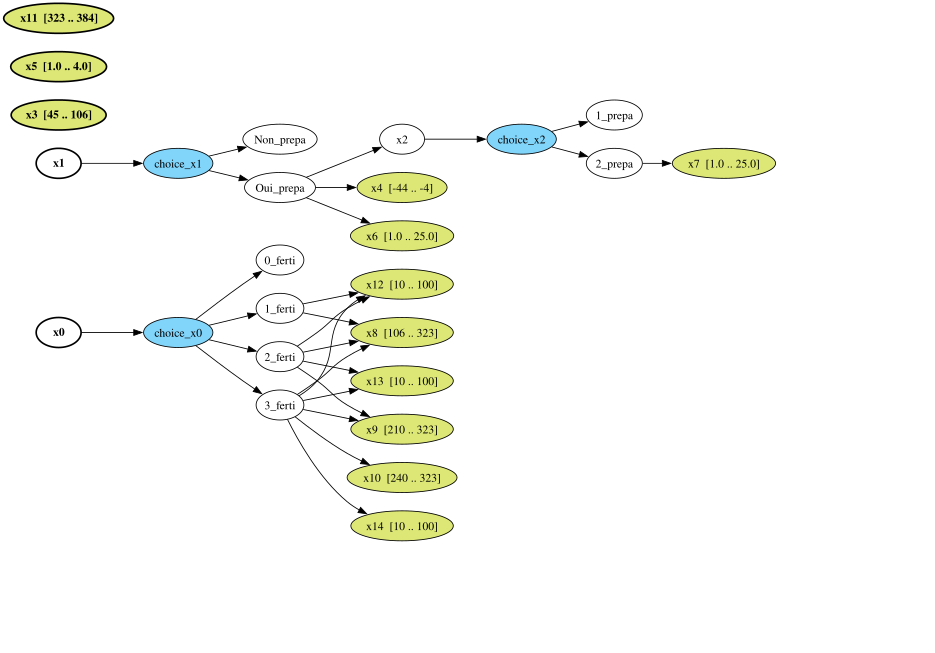

In [6]:
from graphviz import Source
from IPython.display import display

def render_to_image(dsg_obj, filename="temp_graph"):
    dot_str = dsg_obj.export_dot()
    
    # Injection des paramètres de layout dans le DOT
    layout_config = """
    graph [
        rankdir=LR,
        nodesep=0.3,
        ranksep=0.5,
        splines=true,
        margin=0
    ];
    """
    
    # On insère juste après "digraph ..."
    dot_str = dot_str.replace("{", "{\n" + layout_config, 1)
    
    src = Source(dot_str, filename=filename, format="png", engine="dot")
    
    src.render(cleanup=True)
    display(src)

print("=== GRAPHE GLOBAL DE L'ESPACE DE CONCEPTION ===")
render_to_image(agri_design_space.adsg, "maelia_space")


=== GRAPHE GLOBAL DE L'ESPACE DE CONCEPTION MAELIA ===


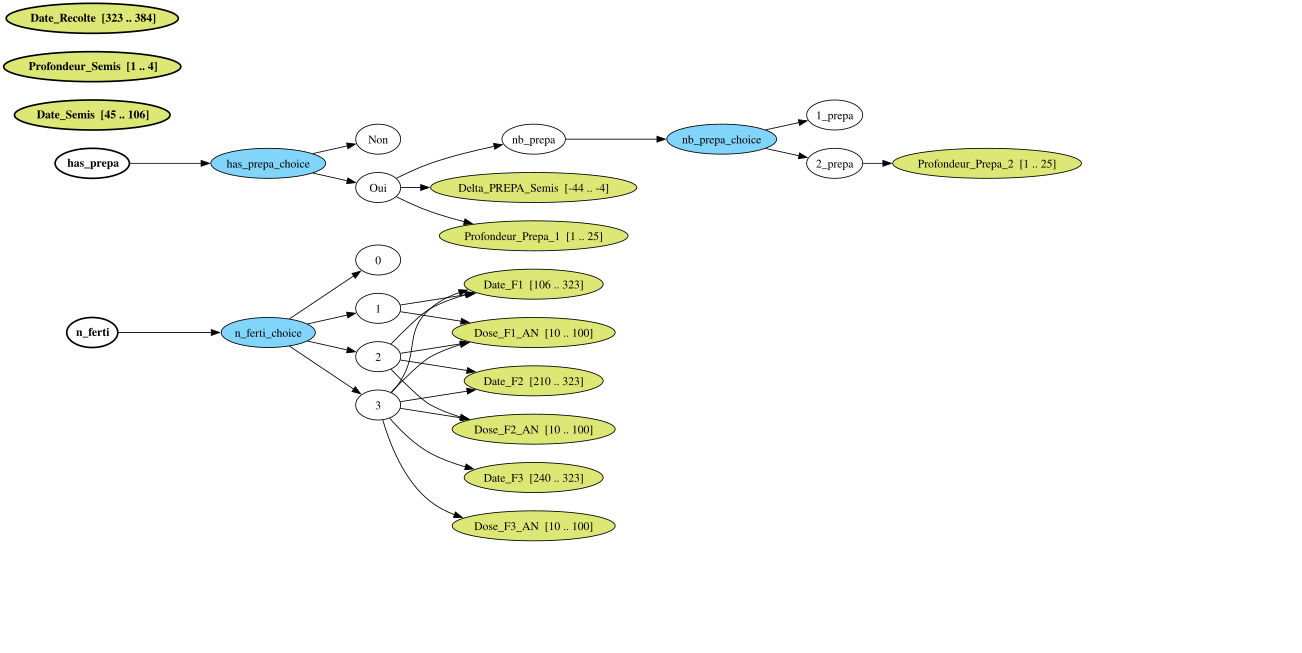

In [7]:
from adsg_core import BasicADSG, DesignVariableNode, NamedNode
from graphviz import Source
from IPython.display import display


def create_explicit_maelia_adsg():
    adsg = BasicADSG()

    # --- 1. ROOT NODES (always active) ---
    n_ferti = NamedNode("n_ferti")
    n_ferti_opts = [NamedNode("0"), NamedNode("1"), NamedNode("2"), NamedNode("3")]
    adsg.add_selection_choice("n_ferti_choice", n_ferti, n_ferti_opts)

    has_prepa = NamedNode("has_prepa")
    has_prepa_opts = [NamedNode("Non"), NamedNode("Oui")]
    adsg.add_selection_choice("has_prepa_choice", has_prepa, has_prepa_opts)

    date_semis = DesignVariableNode("Date_Semis", bounds=(45, 106))
    profondeur_semis = DesignVariableNode("Profondeur_Semis", bounds=(1, 4))
    date_recolte = DesignVariableNode("Date_Recolte", bounds=(323, 384))

    adsg.add_node(date_semis)
    adsg.add_node(profondeur_semis)
    adsg.add_node(date_recolte)

    # --- 2. PREPARATION HIERARCHY ---
    nb_prepa = NamedNode("nb_prepa")
    nb_prepa_opts = [NamedNode("1_prepa"), NamedNode("2_prepa")]
    adsg.add_selection_choice("nb_prepa_choice", nb_prepa, nb_prepa_opts)

    delta_prepa_semis = DesignVariableNode("Delta_PREPA_Semis", bounds=(-44, -4))
    profondeur_prepa_1 = DesignVariableNode("Profondeur_Prepa_1", bounds=(1, 25))

    for node in [nb_prepa, delta_prepa_semis, profondeur_prepa_1]:
        adsg.add_edge(has_prepa_opts[1], node)

    profondeur_prepa_2 = DesignVariableNode("Profondeur_Prepa_2", bounds=(1, 25))
    adsg.add_edge(nb_prepa_opts[1], profondeur_prepa_2)

    # --- 3. FERTILIZATION HIERARCHY ---
    # Le produit fertilisant n'est plus une variable : il est fixé à AN.
    date_f1 = DesignVariableNode("Date_F1", bounds=(106, 323))
    dose_f1 = DesignVariableNode("Dose_F1_AN", bounds=(10, 100))
    for opt_idx in [1, 2, 3]:
        for node in [date_f1, dose_f1]:
            adsg.add_edge(n_ferti_opts[opt_idx], node)

    date_f2 = DesignVariableNode("Date_F2", bounds=(210, 323))
    dose_f2 = DesignVariableNode("Dose_F2_AN", bounds=(10, 100))
    for opt_idx in [2, 3]:
        for node in [date_f2, dose_f2]:
            adsg.add_edge(n_ferti_opts[opt_idx], node)

    date_f3 = DesignVariableNode("Date_F3", bounds=(240, 323))
    dose_f3 = DesignVariableNode("Dose_F3_AN", bounds=(10, 100))
    for node in [date_f3, dose_f3]:
        adsg.add_edge(n_ferti_opts[3], node)

    # --- 4. START NODES ---
    adsg = adsg.set_start_nodes({n_ferti, has_prepa, date_semis, profondeur_semis, date_recolte})
    return adsg


def render_to_image(dsg_obj, filename="temp_graph"):
    dot_str = dsg_obj.export_dot()

    layout_config = """
    graph [
        rankdir=LR,
        nodesep=0.3,
        ranksep=0.5,
        splines=true,
        margin=0
    ];
    """

    dot_str = dot_str.replace("{", "{\n" + layout_config, 1)

    src = Source(dot_str, filename=filename, format="png", engine="dot")
    src.render(cleanup=True)
    display(src)


maelia_adsg = create_explicit_maelia_adsg()

print("=== GRAPHE GLOBAL DE L'ESPACE DE CONCEPTION MAELIA ===")
render_to_image(maelia_adsg, "maelia_adsg")


In [8]:
print("\nEntraînement du Krigeage Hiérarchique SMT (KRG)...")
sm = KRG(design_space=agri_design_space, print_global=False,noise0=[0.01],corr='pow_exp')
sm.set_training_values(xt, yt)
sm.train()
print("Modèle entraîné !")



Entraînement du Krigeage Hiérarchique SMT (KRG)...
exception :  27-th leading minor of the array is not positive definite
[ 1.26244832e+01  3.68753682e+00  2.20971558e+00  1.48594393e+00
  1.33602914e+00  4.05806910e-01  2.75136757e-01  6.83970860e-01
  1.67476053e-01  1.36386559e-01  4.31822673e-02 -9.47602039e-03
  3.57310449e-02  2.72687835e-02  2.27931562e-02  1.71820932e-02
  1.37973397e-02  1.30882526e-02  1.23615431e-02  1.10322717e-02
  1.04061069e-02  1.01304942e-02  1.00168649e-02  1.01000001e+00
  1.00999999e+00  1.01000000e+00  1.01000000e+00  1.01000000e+00
  1.01000000e+00  1.01000000e+00]
exception :  20-th leading minor of the array is not positive definite
[ 1.35797576e+01  3.30872542e+00  1.88713515e+00  1.32232760e+00
  1.38671478e+00  3.88927759e-01  6.33285219e-01  2.22453539e-01
  2.03622475e-01  1.18020177e-01 -4.41880556e-02  4.32798842e-02
  3.33787513e-02  2.58011738e-02  2.17049798e-02  1.80258362e-02
  1.38708760e-02  1.31090894e-02  1.24213550e-02  1.10732

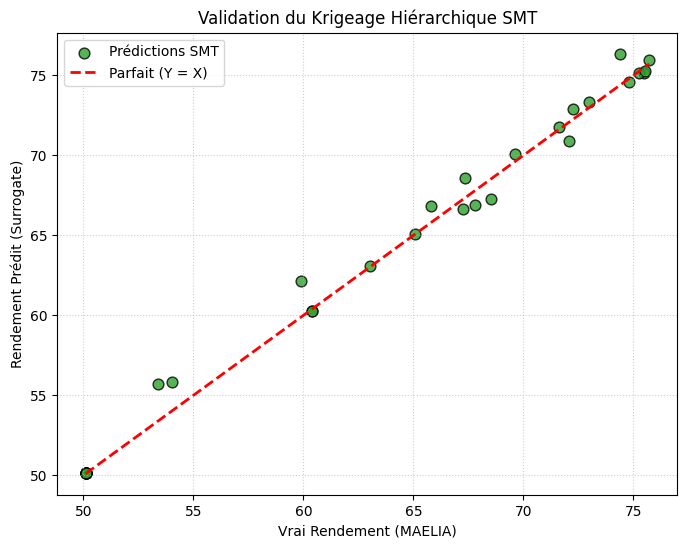

In [9]:

xtest, is_acting_test = agri_design_space._sample_valid_x(30)
ytest_vrai = evaluate_maelia_dummy(xtest, agri_design_space)
ytest_predit = sm.predict_values(xtest)

plt.figure(figsize=(8, 6))
plt.scatter(ytest_vrai, ytest_predit, color='#2ca02c', edgecolors='k', s=60, alpha=0.8, label="Prédictions SMT")
plt.plot([ytest_vrai.min(), ytest_vrai.max()], [ytest_vrai.min(), ytest_vrai.max()], 'r--', lw=2, label="Parfait (Y = X)")
plt.xlabel("Vrai Rendement (MAELIA)")
plt.ylabel("Rendement Prédit (Surrogate)")
plt.title("Validation du Krigeage Hiérarchique SMT")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

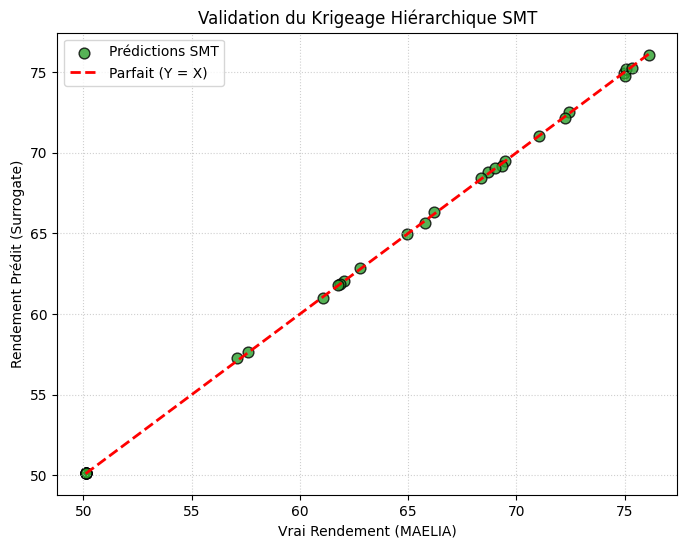

In [10]:
ytest_vrai = evaluate_maelia_dummy(xt, agri_design_space)
ytest_predit = sm.predict_values(xt)

plt.figure(figsize=(8, 6))
plt.scatter(ytest_vrai, ytest_predit, color='#2ca02c', edgecolors='k', s=60, alpha=0.8, label="Prédictions SMT")
plt.plot([ytest_vrai.min(), ytest_vrai.max()], [ytest_vrai.min(), ytest_vrai.max()], 'r--', lw=2, label="Parfait (Y = X)")
plt.xlabel("Vrai Rendement (MAELIA)")
plt.ylabel("Rendement Prédit (Surrogate)")
plt.title("Validation du Krigeage Hiérarchique SMT")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()